## Part 0 - Setup

Run this cell first, in every notebook. It fetches the course repository into the Colab session and moves into the `notebooks/` folder, so that the `../data/...` paths work.

It is safe to run more than once, and safe after a restart.

Note: outside Colab the cell does nothing except report the working directory. Start Jupyter from inside `notebooks/` and the paths work the same way.

If it prints `data ok: True`, you are set.


In [2]:
# --- SETUP: run this first ---  [lares-setup-v1]
# works in Colab and locally, safe to run more than once
import os, sys, subprocess
REPO = "ai_bootcamp_foundations"
if "google.colab" in sys.modules:
    if not os.path.isdir(f"/content/{REPO}"):
        subprocess.run(["git", "clone", "-q",
                        f"https://github.com/mgrubisic/{REPO}.git"],
                       cwd="/content", check=True)
    os.chdir(f"/content/{REPO}/notebooks")
print("cwd:", os.getcwd(), "| data ok:", os.path.isdir("../data"))


cwd: /content/ai_bootcamp_foundations/notebooks | data ok: True


In [3]:
import numpy as np, pandas as pd

# same plot styling as in 1a
import seaborn as sns
sns.set_theme(style="whitegrid")
import matplotlib.pyplot as plt
tex_fonts = {
    "font.family": "serif",
    # Use 26pt font in plots
    "axes.labelsize": 20,
    "font.size": 20,
    "figure.titlesize": 20,
    # Make the legend/label fonts a little smaller
    "legend.title_fontsize": 18,
    "legend.fontsize": 18,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18
}

plt.rcParams.update(tex_fonts)


In [4]:
# The sub-folder ``supervised_learning`` sits one level deeper than the
# shared ``data`` folder, so we add another ``../`` when needed.
DATA_DIR = "../data" if os.path.isdir("../data") else "../../data"
print("data folder:", DATA_DIR)


data folder: ../data


# Regression Fundamentals and Regularization

**Student exercise - notebook `1_Regression_Fundamentals`**

We start with simple linear regression on one housing feature, then progressively add more features from the dataset, and finally use all features to see how Ridge and Lasso control multiple linear regression.


## Part 1 - Load the housing data

We reuse the same train and test split as the other course notebooks. The features live in `data/housing_prices/`. The dataset has ten numeric features that describe each house.


In [5]:
X_train = pd.read_csv(f"{DATA_DIR}/housing_prices/X_train.csv", index_col="Id")
X_test = pd.read_csv(f"{DATA_DIR}/housing_prices/X_test.csv", index_col="Id")
y_train = pd.read_csv(f"{DATA_DIR}/housing_prices/y_train.csv", index_col="Id").squeeze()
y_test = pd.read_csv(f"{DATA_DIR}/housing_prices/y_test.csv", index_col="Id").squeeze()

print("train houses:", len(X_train))
print("test houses :", len(X_test))
print("features    :", list(X_train.columns))
X_train.head()


train houses: 1167
test houses : 292
features    : ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd
Id,,,,,,,,,,
758,6,1386,2,440,672,672,2,6,1978,1978
599,5,1647,2,621,1430,1647,2,7,1977,1977
216,5,1236,1,447,1070,1236,1,6,1957,1996
136,7,1682,2,530,1304,1682,2,7,1970,1970
373,6,752,1,264,744,752,1,4,1984,1984


## Part 2 - Standardise every feature

Different features are measured in different units: `GrLivArea` is in square feet, `YearBuilt` is a year, `OverallQual` is a 1-10 rating. Comparing coefficients or applying a regularisation penalty across features only makes sense if every feature lives on the same scale.

**Standard scaling formula:** `x_scaled = (x - mean) / std`.

We fit `StandardScaler` on the training features only, then apply the same transformation to the test features. This avoids leaking information from the test set into the training pipeline.


In [6]:
from sklearn.preprocessing import StandardScaler

# Standardisation is a data-prep step, so it is done for you.
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), index=X_train.index, columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

# sanity check: every scaled column should have mean ~0 and std ~1 on the training set
X_train_scaled.describe().loc[["mean", "std"]].round(2)

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd
mean,0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Part 3 - Simple linear regression on one feature

We first predict the sale price from a single feature: `GrLivArea` (above-ground living area). This lets us draw the model on a 2D plot.

scikit-learn's `LinearRegression` always expects a 2D table: rows are samples, columns are features. Our one-feature input is a 1D Series, so we must turn it into a 2D table with one column.

The easiest way is `.to_frame()`, which wraps the Series in a single-column DataFrame. You may also see `.values.reshape(-1, 1)` in older code: `-1` means 'keep all rows, infer the count automatically', and `1` means 'one column'. Both approaches produce the same shape.


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# The one-feature train/test tables are prepared for you.
X_train_1 = X_train_scaled[["GrLivArea"]]
X_test_1 = X_test_scaled[["GrLivArea"]]

# TODO 1: create a LinearRegression and fit it on X_train_1, y_train
model_1 = LinearRegression().fit(X_train_1, y_train)

# TODO 2: predict on X_train_1 and on X_test_1
pred_1_train = model_1.predict(X_train_1)
pred_1_test = model_1.predict(X_test_1)

print(f"train MSE: {mean_squared_error(y_train, pred_1_train):,.0f}")
print(f"test  MSE: {mean_squared_error(y_test, pred_1_test):,.0f}")

train MSE: 3,219,483,181
test  MSE: 2,833,364,808


### Plot the fitted line

The line is drawn on the scaled `GrLivArea` axis.


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


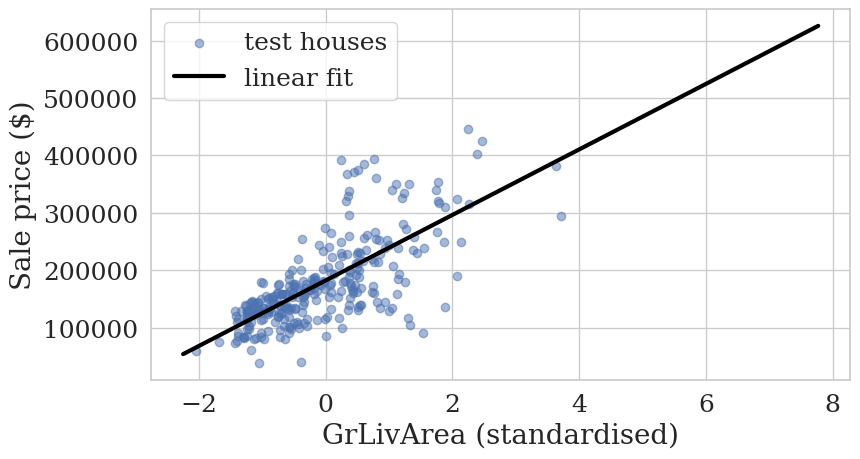

In [9]:
x_grid = np.linspace(X_train_scaled["GrLivArea"].min(), X_train_scaled["GrLivArea"].max(), 200).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(X_test_scaled["GrLivArea"], y_test, alpha=0.5, label="test houses")
ax.plot(x_grid, model_1.predict(x_grid), color="black", linewidth=3, label="linear fit")
ax.set_xlabel("GrLivArea (standardised)")
ax.set_ylabel("Sale price ($)")
ax.legend()
plt.tight_layout()
plt.show()


## Part 4 - Residuals of the one-feature model

A **residual** is `actual - predicted`. If the model captures the pattern well, residuals should look like a random cloud around zero. If they show a shape, the model is missing some information.


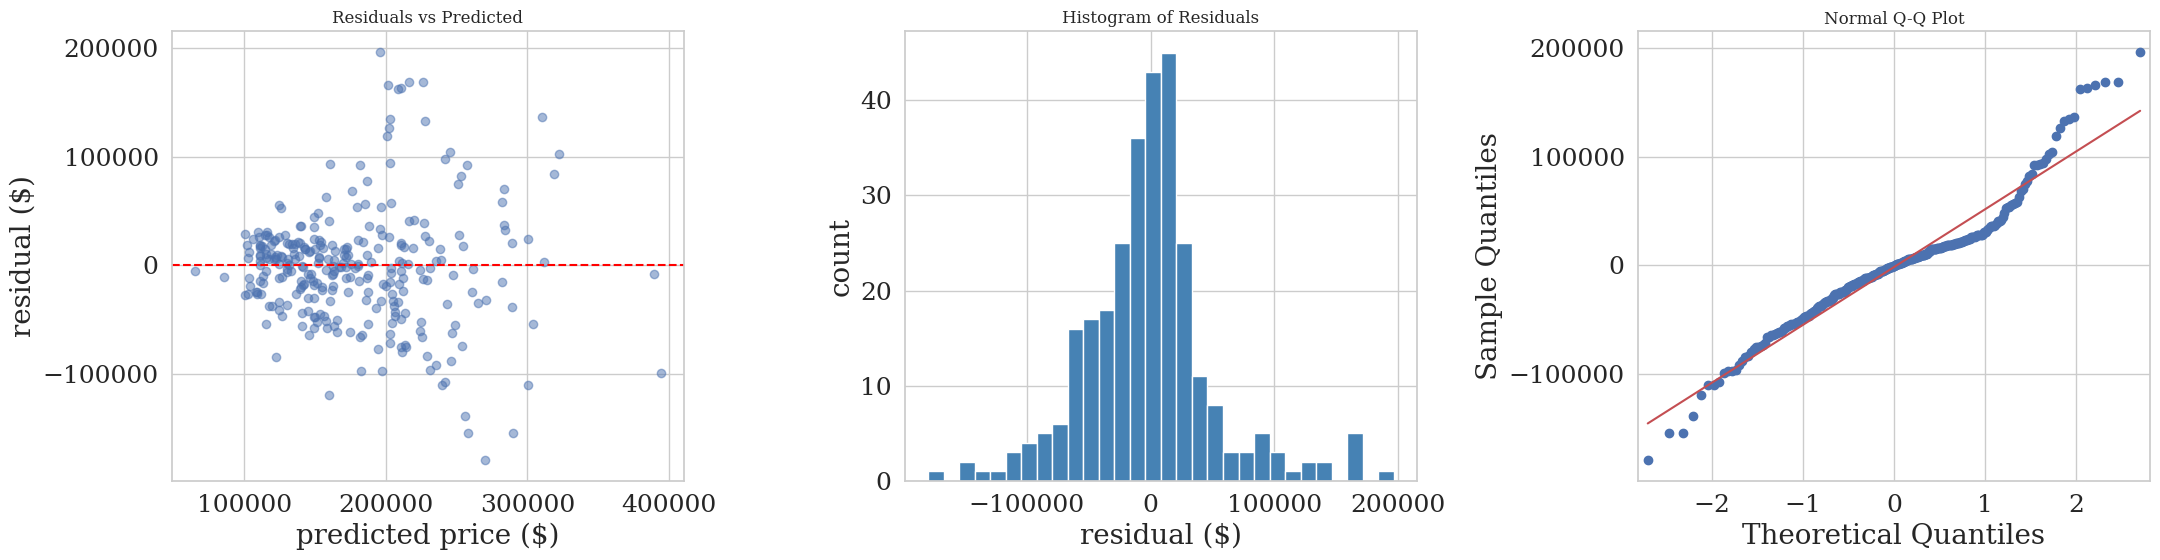

In [22]:
import scipy.stats as stats
import statsmodels.api as sm

residuals_1 = y_test.values - pred_1_test

# Create 3 subplots side-by-side in a single row
fig, ax = plt.subplots(1, 3, figsize=(22, 6))

# Subplot 1: Residual Scatter plot
ax[0].scatter(pred_1_test, residuals_1, alpha=0.5)
ax[0].axhline(0, color="red", linestyle="--")
ax[0].set_xlabel("predicted price ($)")
ax[0].set_ylabel("residual ($)")
ax[0].set_title("Residuals vs Predicted")

# Subplot 2: Residual Histogram
ax[1].hist(residuals_1, bins=30, color="steelblue", edgecolor="white")
ax[1].set_xlabel("residual ($)")
ax[1].set_ylabel("count")
ax[1].set_title("Histogram of Residuals")

# Subplot 3: Normal Q-Q Plot
sm.qqplot(residuals_1, line='s', ax=ax[2])
ax[2].set_title("Normal Q-Q Plot")

plt.tight_layout()
plt.show()

## Part 5 - Add more features from the dataset

Instead of inventing new columns like `x^2` or `x^3`, we simply add more features that are already in the dataset. Each extra feature gives the linear model one more knob to turn.

We define three feature sets of increasing size:

* **1 feature**: `GrLivArea`
* **3 features**: `GrLivArea`, `OverallQual`, `GarageCars`
* **All 10 features**: every column in the dataset

The three-feature set uses the columns that correlate most strongly with the sale price. You can pick a different subset if you want to experiment.


In [11]:
feature_sets = {
    "1 feature":   ["GrLivArea"],
    "3 features":  ["GrLivArea", "OverallQual", "GarageCars"],
    "10 features": list(X_train_scaled.columns),
}

for name, cols in feature_sets.items():
    print(f"{name:12s} -> {cols}")


1 feature    -> ['GrLivArea']
3 features   -> ['GrLivArea', 'OverallQual', 'GarageCars']
10 features  -> ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


## Part 6 - Train one linear model per feature set

We loop over the three feature sets, fit a `LinearRegression` on each, and store the trained model and its MSE on train and test.


In [12]:
trained_models = {}
scores = []

for name, cols in feature_sets.items():
    # Column selection is done for you.
    X_tr = X_train_scaled[cols]
    X_te = X_test_scaled[cols]

    # TODO 3: create a LinearRegression, fit it on X_tr / y_train,
    #         then predict on X_tr and X_te (call them train_pred and test_pred)
    model = LinearRegression().fit(X_tr, y_train)
    train_pred = model.predict(X_tr)
    test_pred = model.predict(X_te)

    trained_models[name] = model
    scores.append({
        "features": name,
        "train_MSE": mean_squared_error(y_train, train_pred),
        "test_MSE": mean_squared_error(y_test, test_pred),
    })

scores_df = pd.DataFrame(scores).set_index("features")
scores_df.round(0)

,train_MSE,test_MSE
features,,
1 feature,3.219483e+09,2.833365e+09
3 features,1.746018e+09,1.254415e+09
10 features,1.544801e+09,9.792205e+08


## Part 7 - Compare the three models on the `GrLivArea` axis

All three models predict a single price for each house. To draw them on one plot, we project the predictions onto the `GrLivArea` axis: each dot is a test house at its actual `GrLivArea`, coloured by which model made the prediction.


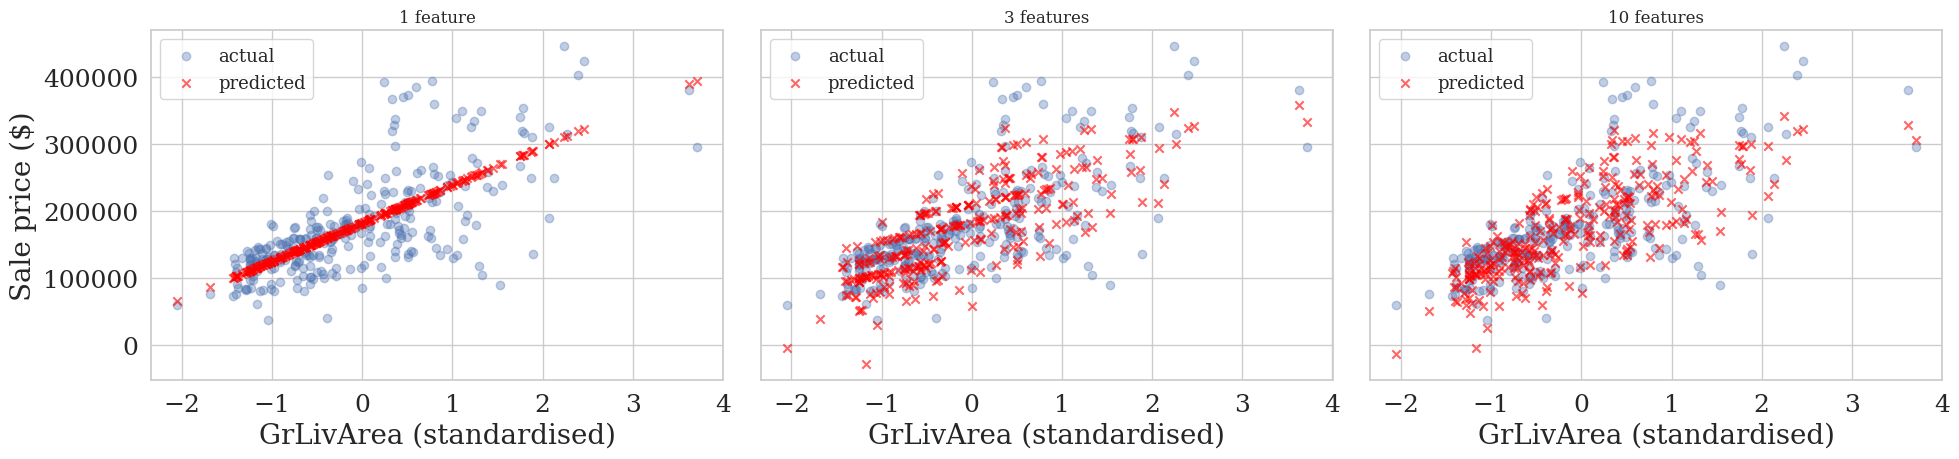

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, (name, cols) in zip(axes, feature_sets.items()):
    y_pred = trained_models[name].predict(X_test_scaled[cols])
    ax.scatter(X_test_scaled["GrLivArea"], y_test, alpha=0.35, label="actual")
    ax.scatter(X_test_scaled["GrLivArea"], y_pred, alpha=0.6, color="red", marker="x", label="predicted")
    ax.set_xlabel("GrLivArea (standardised)")
    ax.set_title(name)
    ax.legend(fontsize=13)

axes[0].set_ylabel("Sale price ($)")
plt.tight_layout()
plt.show()

## Part 8 - Train MSE vs. test MSE

A bar chart lines up the training and test error for each feature set.


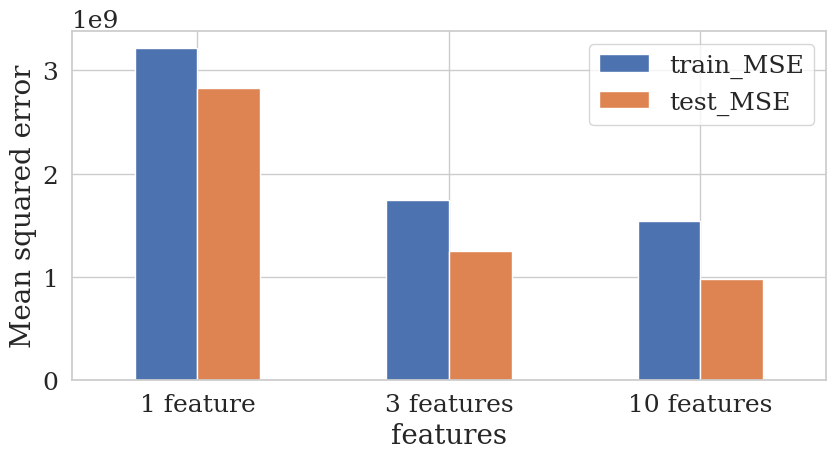

In [14]:
ax = scores_df[["train_MSE", "test_MSE"]].plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Mean squared error")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Part 9 - Ridge and Lasso on all features

With all 10 standardised features we now compare three models:

* `LinearRegression` has no penalty at all.
* `Ridge(alpha=10)` adds a squared-size penalty (L2).
* `Lasso(alpha=2000)` adds an absolute-size penalty (L1). Lasso can shrink some coefficients to **exactly zero**, effectively picking features.

`alpha` controls the penalty strength. We pick values here that are large enough to zero out some Lasso coefficients so the effect is visible on the plot below.

**How to choose alpha in practice:** never guess. Use `RidgeCV` or `LassoCV` (from `sklearn.linear_model`) which try a range of alpha values and pick the one with the best cross-validation score. The fixed values here are for illustration; Part 12 shows what happens as alpha changes.


In [16]:
from sklearn.linear_model import Ridge, Lasso

# TODO 4: fit three models on X_train_scaled, y_train:
#   - a plain LinearRegression
#   - a Ridge with alpha=10
#   - a Lasso with alpha=2000 (use max_iter=20000 so it converges)
linear = LinearRegression().fit(X_train_scaled, y_train)
ridge = Ridge(alpha=10).fit(X_train_scaled, y_train)
lasso = Lasso(alpha=2000, max_iter=20000).fit(X_train_scaled, y_train)

models = {"Linear": linear, "Ridge (L2)": ridge, "Lasso (L1)": lasso}

# TODO 5: for each model, predict on X_test_scaled and record its test MSE.
#         Fill in `test_pred` inside the loop; the rest is prepared.
metric_rows = []
for label, model in models.items():
    test_pred = model.predict(X_test_scaled)
    metric_rows.append({
        "model": label,
        "test_MSE": mean_squared_error(y_test, test_pred),
    })

pd.DataFrame(metric_rows).set_index("model").round(0)

,test_MSE
model,
Linear,9.792205e+08
Ridge (L2),9.785042e+08
Lasso (L1),1.002537e+09


## Part 10 - Compare the coefficients

Each model stores its learned coefficients in `.coef_` (a NumPy array). We collect these into a DataFrame so one bar chart can compare all three models. A dictionary comprehension `{name: model.coef_ for name, model in models.items()}` builds the columns, and we pass the feature names as the index.


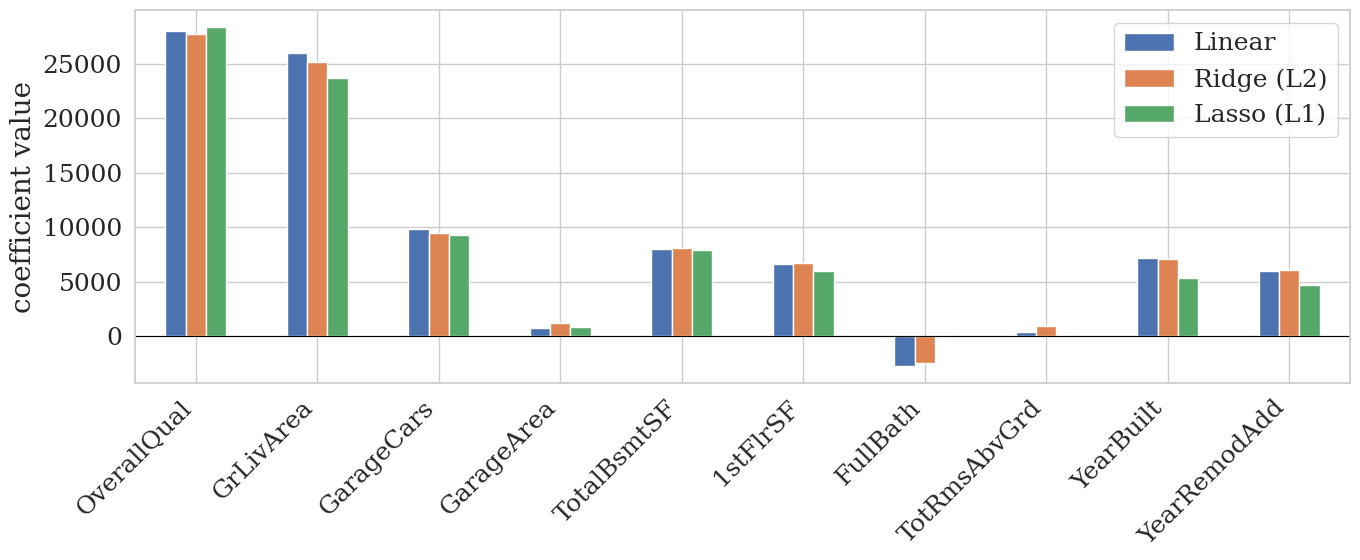

Lasso coefficients equal to zero: 2


In [17]:
coefficients = pd.DataFrame(
    {label: model.coef_ for label, model in models.items()},
    index=X_train_scaled.columns,
)

ax = coefficients.plot(kind="bar", figsize=(14, 6))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("coefficient value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Lasso coefficients equal to zero:", int((coefficients["Lasso (L1)"] == 0).sum()))

## Part 11 - How the penalty strength (alpha) changes Lasso

`alpha` is the size of the penalty. As alpha grows, more Lasso coefficients get pushed to zero. The curves below show that transition.


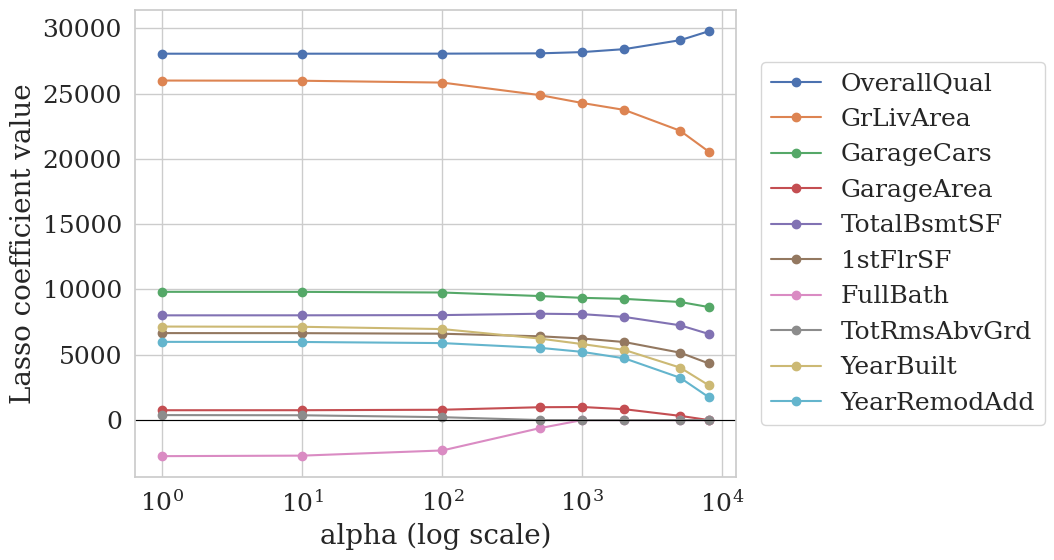

In [18]:
alpha_values = [1, 10, 100, 500, 1000, 2000, 5000, 8000]
lasso_paths = []
for a in alpha_values:
    fit = Lasso(alpha=a, max_iter=20000).fit(X_train_scaled, y_train)
    lasso_paths.append(pd.Series(fit.coef_, index=X_train_scaled.columns, name=a))
lasso_paths_df = pd.concat(lasso_paths, axis=1).T
lasso_paths_df.index.name = "alpha"

fig, ax = plt.subplots(figsize=(11, 6))
for column in lasso_paths_df.columns:
    ax.plot(lasso_paths_df.index, lasso_paths_df[column], marker="o", label=column)
ax.set_xscale("log")
ax.set_xlabel("alpha (log scale)")
ax.set_ylabel("Lasso coefficient value")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()


### Conclusions - overall:
*   Standardising every feature first puts all columns on the same scale, so coefficients and penalties are comparable.
*   Simple linear regression on one feature is easy to draw and easy to interpret.
*   Residual plots reveal patterns that a single MSE number hides.
*   Adding more features from the dataset gives the linear model more information to work with.
*   Ridge shrinks multiple-regression coefficients with an L2 penalty.
*   Lasso uses an L1 penalty and can set selected coefficients exactly to zero.

_University of Zagreb Faculty of Electrical Engineering and Computing_  
_Laboratory for Renewable Energy Systems_  

_Course: AI bootcamp - basic_  
_Notebook: 1_Regression_Fundamentals_  

_Website: [www.lares.fer.hr](https://www.lares.fer.hr/)_  
_Contact: [Hrvoje Novak](mailto:hrvoje.novak@fer.hr)_
